## 1. Setup and Libraries


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import scipy.cluster.hierarchy as sch
import scipy.stats as stats

warnings.filterwarnings('ignore')

# Premium graphical configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 15

# Modern custom palette
modern_palette = ["#2B2D42", "#3A86C8", "#4E9F3D", "#FAB733", "#FF6B6B", "#8D99AE"]
sns.set_palette(sns.color_palette(modern_palette))

# Loading the dataset
file_path = "Database_STATA_EN/Database_ENG.dta"
try:
    df = pd.read_stata(file_path)
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
except Exception as e:
    print(f"Error: {e}")


Dataset loaded: 4862 rows, 219 columns.


## 2. Feature Selection and Standardization


In [12]:
# 1. Construction of the three composite dimensions
classical_answers = {
    'qk3': 3, 'qk4': 0, 'qk5': 102, 'qk6': 1,
    'qk7_1': 1, 'qk7_2': 1, 'qk7_3': 1, 'qk10': 1
}
digital_answers = {
    'qk7_4': 0, 'qk7_5': 1, 'qk7_6': 0
}

# Creating columns for correct answers
for q, correct in classical_answers.items():
    df[f'{q}_correct'] = (df[q] == correct).astype(int)
for q, correct in digital_answers.items():
    df[f'{q}_correct'] = (df[q] == correct).astype(int)

classical_cols = [f'{q}_correct' for q in classical_answers.keys()]
digital_cols = [f'{q}_correct' for q in digital_answers.keys()]

df['Classical Knowledge'] = df[classical_cols].sum(axis=1)
df['Digital Knowledge'] = df[digital_cols].sum(axis=1)

# Fintech Adoption Index (FAI)
qp8_cols = ['qp8_1', 'qp8_2', 'qp8_3', 'qp8_4', 'qp8_5']
qp9_cols = ['qp9_1', 'qp9_3', 'qp9_4', 'qp9_5', 'qp9_6', 'qp9_7']

qp8_score = df[qp8_cols].apply(lambda x: (x == 1).astype(int)).sum(axis=1)
def map_qp9_freq(x):
    return x.apply(lambda val: val - 1 if val in [1, 2, 3, 4] else 0)
qp9_mapped = df[qp9_cols].apply(map_qp9_freq)
qp9_score = qp9_mapped.sum(axis=1)
df['Fintech Adoption'] = qp8_score + qp9_score

# 2. Feature selection and dropping NaNs in indices
cluster_cols = ['Classical Knowledge', 'Digital Knowledge', 'Fintech Adoption']
X_raw = df[cluster_cols].dropna()

# 3. Feature Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=cluster_cols)

print(f"Number of valid records for clustering: {X_scaled.shape[0]}")
print("\nDescriptive statistics of the original variables:")
print(X_raw.describe())


Number of valid records for clustering: 4862

Descriptive statistics of the original variables:
       Classical Knowledge  Digital Knowledge  Fintech Adoption
count          4862.000000        4862.000000       4862.000000
mean              4.606541           1.294529          6.505142
std               2.112663           1.006279          4.821081
min               0.000000           0.000000          0.000000
25%               3.000000           0.000000          2.000000
50%               5.000000           1.000000          6.000000
75%               6.000000           2.000000         10.000000
max               8.000000           3.000000         23.000000


## 3. Model 1: K-Means Clustering


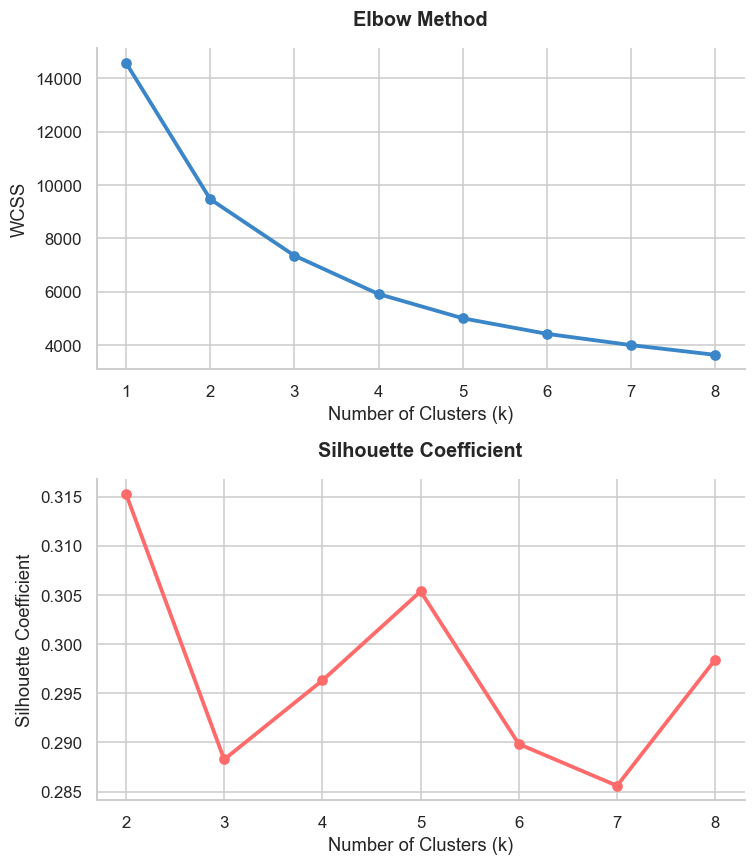

In [13]:
wcss = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    # Calculating on a sample to speed up execution
    sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=min(2000, len(X_scaled)), replace=False)
    silhouette_scores.append(silhouette_score(X_scaled.iloc[sample_idx], labels[sample_idx]))

# For the complete elbow curve
kmeans_1 = KMeans(n_clusters=1, random_state=42, n_init=10)
kmeans_1.fit(X_scaled)
wcss_complete = [kmeans_1.inertia_] + wcss
K_range_complete = [1] + list(K_range)

fig, axes = plt.subplots(2, 1, figsize=(7, 8))

# 1. Elbow Curve
axes[0].plot(K_range_complete, wcss_complete, 'bo-', color="#3A86C8", linewidth=2.5)
axes[0].set_title("Elbow Method", fontsize=13)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("WCSS")
axes[0].set_xticks(K_range_complete)

# 2. Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', color="#FF6B6B", linewidth=2.5)
axes[1].set_title("Silhouette Coefficient", fontsize=13)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Coefficient")
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

# Final execution with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)


In [14]:
# 1. Assigning K-Means labels (already fitted in the previous cell)
kmeans_labels = kmeans_labels

# 2. Training Agglomerative Hierarchical Clustering (K=4, Ward linkage)
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# 3. Training Gaussian Mixture Model (4 components, probabilistic clustering)
gmm = GaussianMixture(n_components=4, random_state=42, n_init=5)
gmm_labels = gmm.fit_predict(X_scaled)

# 4. Calculating metrics for model comparison
np.random.seed(42)
eval_sample_idx = np.random.choice(len(X_scaled), size=min(3000, len(X_scaled)), replace=False)
X_eval = X_scaled.iloc[eval_sample_idx]

metrics = []
models_list = [
    ("K-Means", kmeans_labels),
    ("Hierarchical Clustering", hierarchical_labels),
    ("Gaussian Mixture Model (GMM)", gmm_labels)
]

for name, labels in models_list:
    sil = silhouette_score(X_eval, labels[eval_sample_idx], random_state=42)
    ch = calinski_harabasz_score(X_scaled, labels)
    
    # F-statistic of the one-way ANOVA for each of the 3 clustering dimensions
    unique_labels = np.unique(labels)
    f_class, _ = stats.f_oneway(*[X_scaled['Classical Knowledge'][labels == c] for c in unique_labels])
    f_dig, _ = stats.f_oneway(*[X_scaled['Digital Knowledge'][labels == c] for c in unique_labels])
    f_fai, _ = stats.f_oneway(*[X_scaled['Fintech Adoption'][labels == c] for c in unique_labels])
    
    metrics.append({
        "Model": name, 
        "Silhouette Score": sil, 
        "Calinski-Harabasz": ch,
        "F-Stat (Classical)": f_class,
        "F-Stat (Digital)": f_dig,
        "F-Stat (Fintech)": f_fai
    })

# Creating and printing the comparative DataFrame
df_comparison = pd.DataFrame(metrics)
print("=== CLUSTERING MODEL COMPARISON TABLE (K=4) ===")
print(df_comparison.round(3).to_string(index=False))


=== CLUSTERING MODEL COMPARISON TABLE (K=4) ===
                       Model  Silhouette Score  Calinski-Harabasz  F-Stat (Classical)  F-Stat (Digital)  F-Stat (Fintech)
                     K-Means             0.295           2373.307            1786.930          3024.329          2505.087
     Hierarchical Clustering             0.244           1699.258            1853.968          1653.652          1600.696
Gaussian Mixture Model (GMM)             0.165           1162.071             290.649               inf           182.381


## 4. Model 2: Agglomerative Hierarchical Clustering


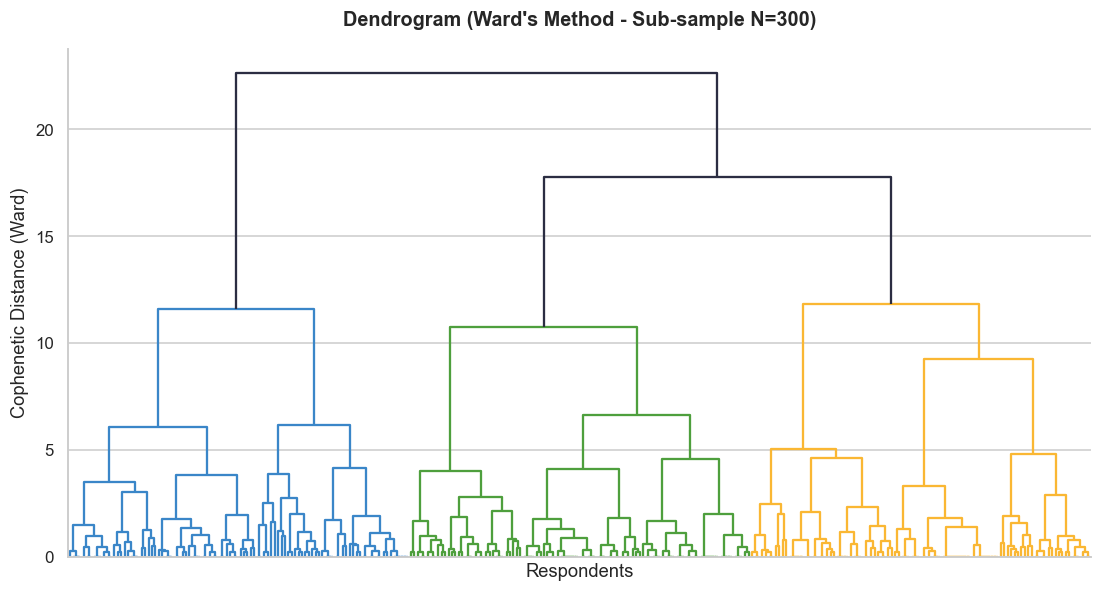

Hierarchical Clustering fit completed with 4 clusters!


In [15]:
# Extracting a random sample to visualize the Dendrogram
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=300, replace=False)
X_sample = X_scaled.iloc[sample_idx]

plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_sample, method='ward'), no_labels=True)
plt.title("Dendrogram (Ward's Method - Sub-sample N=300)", fontsize=13)
plt.xlabel("Respondents")
plt.ylabel("Cophenetic Distance (Ward)")
plt.show()

# Fit hierarchical model on the complete dataset
hierarchical_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical_model.fit_predict(X_scaled)
print("Hierarchical Clustering fit completed with 4 clusters!")


## 5. Model 3: Gaussian Mixture Model (GMM)


In [16]:
# Training GMM model with 4 components
gmm_model = GaussianMixture(n_components=4, random_state=42, n_init=5)
gmm_labels = gmm_model.fit_predict(X_scaled)
print("GMM fit completed with 4 components!")


GMM fit completed with 4 components!


## 6. Performance Comparison and Model Selection


In [17]:
np.random.seed(42)
eval_sample_idx = np.random.choice(len(X_scaled), size=min(3000, len(X_scaled)), replace=False)
X_eval = X_scaled.iloc[eval_sample_idx]

metrics = []
models = [
    ("K-Means", kmeans_labels),
    ("Hierarchical Clustering", hierarchical_labels),
    ("Gaussian Mixture Model (GMM)", gmm_labels)
]

for name, labels in models:
    sil = silhouette_score(X_eval, labels[eval_sample_idx], random_state=42)
    ch = calinski_harabasz_score(X_scaled, labels)
    metrics.append({"Model": name, "Silhouette Coefficient": sil, "Calinski-Harabasz Index": ch})

df_comparison = pd.DataFrame(metrics)
print("=== STATISTICAL MODEL COMPARISON ===")
print(df_comparison.to_string(index=False))

best_model_name = df_comparison.loc[df_comparison['Silhouette Coefficient'].idxmax()]['Model']
print(f"\nOptimal Model Selected (Highest Silhouette): {best_model_name}")


=== STATISTICAL MODEL COMPARISON ===
                       Model  Silhouette Coefficient  Calinski-Harabasz Index
                     K-Means                0.295048              2373.307349
     Hierarchical Clustering                0.243550              1699.257761
Gaussian Mixture Model (GMM)                0.165232              1162.070936

Optimal Model Selected (Highest Silhouette): K-Means


## 7. Profiling and Interpretation of Selected Clusters


--- Centroid Profiles (Original values): ---
         Classical Knowledge  Digital Knowledge  Fintech Adoption   % Sample
cluster                                                                     
0                   5.460600           2.395872          4.671670  21.925134
1                   4.971059           1.853008         12.442498  27.005348
2                   1.652044           0.375872          2.426720  20.629371
3                   5.670270           0.628378          5.322297  30.440148


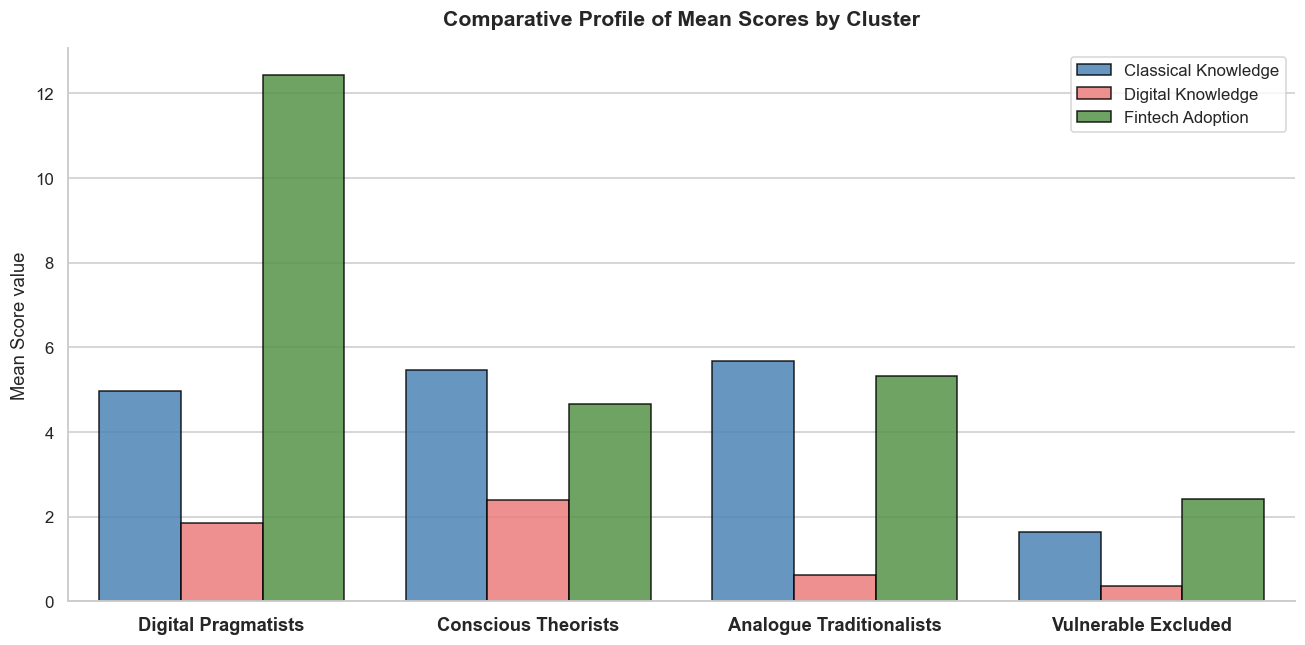

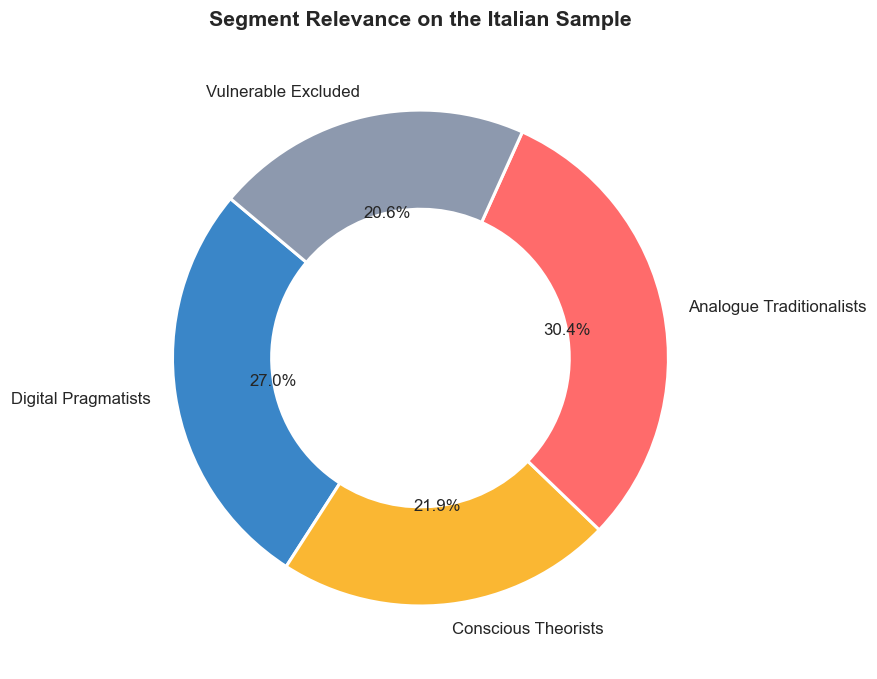

In [18]:
X_raw['cluster'] = kmeans_labels

# Calculating real centroids
profiles = X_raw.groupby('cluster')[cluster_cols].mean()
profiles['% Sample'] = X_raw.groupby('cluster').size() / len(X_raw) * 100
print("--- Centroid Profiles (Original values): ---")
print(profiles)

# Assigning descriptive names based on centroid values (stable with random_state=42)
cluster_names = {
    0: "Conscious Theorists",
    1: "Digital Pragmatists",
    2: "Vulnerable Excluded",
    3: "Analogue Traditionalists"
}
X_raw['cluster_label'] = X_raw['cluster'].map(cluster_names)

# 1. Comparative plot of mean scores by cluster
profiles_melted = X_raw.groupby('cluster_label', observed=False)[cluster_cols].mean().reset_index().melt(id_vars='cluster_label')

# Specific order required by the report paragraph
order_list = ["Digital Pragmatists", "Conscious Theorists", "Analogue Traditionalists", "Vulnerable Excluded"]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=profiles_melted, 
    x='cluster_label', 
    y='value', 
    hue='variable', 
    order=order_list,  # Force order of categories on X-axis
    palette=["#3A86C8", "#FF6B6B", "#4E9F3D"], 
    edgecolor="black", 
    alpha=0.85
)
plt.title("Comparative Profile of Mean Scores by Cluster", fontsize=14, pad=15)
plt.xlabel("")
plt.ylabel("Mean Score value")
plt.legend(title="")
plt.xticks(fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

# 2. Donut chart of cluster size
sizes = X_raw['cluster_label'].value_counts().reindex(order_list)
plt.figure(figsize=(8, 8))
plt.pie(
    sizes, 
    labels=sizes.index, 
    autopct='%1.1f%%', 
    startangle=140,
    colors=["#3A86C8", "#FAB733", "#FF6B6B", "#8D99AE"],
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)
plt.title("Segment Relevance on the Italian Sample", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


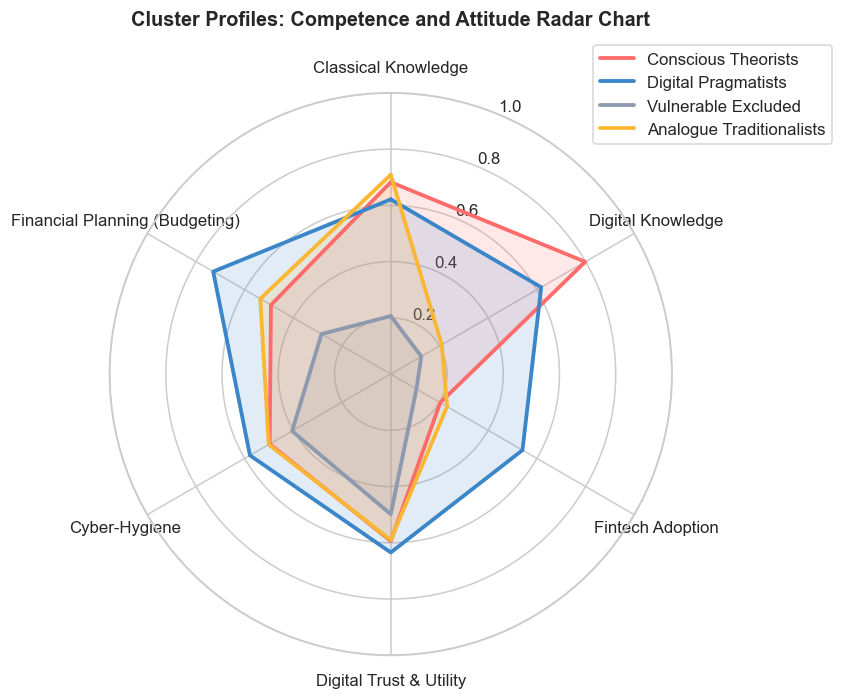

In [19]:
# 3. Preparing behavioral and attitudinal data for the Radar Plot
df_att = df[['qs4_4', 'qs3_13', 'qf2_5']].copy()
missing_codes_att = [-99, -98, -97, -999, -99.0, -98.0, -97.0, -999.0]
for code in missing_codes_att:
    df_att = df_att.replace(code, np.nan)

X_raw['trust_fintech'] = df_att['qs4_4']
X_raw['cyber_security'] = df_att['qs3_13']
X_raw['budgeting_app'] = df_att['qf2_5']

# Automatic detection of column casing in the DataFrame
class_col = 'Classical Knowledge' if 'Classical Knowledge' in X_raw.columns else 'classical_knowledge'
dig_col = 'Digital Knowledge' if 'Digital Knowledge' in X_raw.columns else 'digital_knowledge'
fai_col = 'Fintech Adoption' if 'Fintech Adoption' in X_raw.columns else 'fintech_adoption'

# Creation of the normalized DataFrame (0-1)
radar_df = pd.DataFrame()
radar_df['cluster'] = X_raw['cluster']
radar_df['Classical Knowledge'] = X_raw[class_col] / 8.0
radar_df['Digital Knowledge'] = X_raw[dig_col] / 3.0
radar_df['Fintech Adoption'] = X_raw[fai_col] / 23.0
radar_df['Digital Trust & Utility'] = (5.0 - X_raw['trust_fintech']) / 4.0
radar_df['Cyber-Hygiene'] = (5.0 - X_raw['cyber_security']) / 4.0
radar_df['Financial Planning (Budgeting)'] = X_raw['budgeting_app']

radar_means = radar_df.groupby('cluster').mean()

# Drawing the Radar Plot
labels_radar = [
    'Classical Knowledge', 
    'Digital Knowledge', 
    'Fintech Adoption', 
    'Digital Trust & Utility', 
    'Cyber-Hygiene', 
    'Financial Planning (Budgeting)'
]
num_vars = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

cluster_colors = {
    0: "#FF6B6B", # Conscious Theorists (Coral)
    1: "#3A86C8", # Digital Pragmatists (Blue)
    2: "#8D99AE", # Vulnerable Excluded (Grey)
    3: "#FAB733"  # Analogue Traditionalists (Yellow)
}

cluster_names_en = {
    0: "Conscious Theorists",
    1: "Digital Pragmatists",
    2: "Vulnerable Excluded",
    3: "Analogue Traditionalists"
}

for i in range(4):
    values = radar_means.iloc[i].values.tolist()
    values += values[:1]
    ax.plot(angles, values, color=cluster_colors[i], linewidth=2.5, label=cluster_names_en[i])
    ax.fill(angles, values, color=cluster_colors[i], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels_radar)
ax.set_ylim(0, 1.0)

plt.title("Cluster Profiles: Competence and Attitude Radar Chart", y=1.08, fontsize=13, weight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


## 8. Socio-Demographic Cross-Tabulation


In [20]:
# Set up demographic and socio-economic variables for cross-tabulation
df_dem = df[['qd1', 'qd2', 'qd7', 'qd9', 'qd10', 'qd13', 'qk1', 'qp7_add1']].copy()
missing_codes = [-99, -98, -97, -999, -99.0, -98.0, -97.0, -999.0]
for code in missing_codes:
    df_dem = df_dem.replace(code, np.nan)

X_raw['gender'] = df_dem['qd1'].map({1: 'Male', 0: 'Female'})
X_raw['age'] = df_dem['qd7']

education_mapping = {
    1: 'University or higher', 2: 'University or higher', 3: 'University or higher',
    4: 'High school diploma', 5: 'High school diploma', 
    6: 'Up to middle school', 7: 'Up to middle school', 8: 'Up to middle school',
    9: 'Up to middle school', 10: 'Up to middle school'
}
X_raw['education'] = df_dem['qd9'].map(education_mapping)

X_raw['geo_area'] = df_dem['qd2'].map({1: 'North', 2: 'North', 3: 'Center', 4: 'South and Islands', 5: 'South and Islands'})

employment_mapping = {
    1: 'Employed', 2: 'Employed', 3: 'Employed',
    4: 'Homemaker',
    5: 'Unemployed',
    6: 'Retired',
    9: 'Student',
    7: 'Inactive/Other', 8: 'Inactive/Other', 10: 'Inactive/Other'
}
X_raw['employment'] = df_dem['qd10'].map(employment_mapping)

X_raw['income'] = df_dem['qd13'].map({1: 'Low (<1750€)', 2: 'Medium (1751-2900€)', 3: 'High (>2900€)'})

X_raw['risk_tolerance'] = df_dem['qp7_add1'].map({
    1: 'High (Very High/High)', 2: 'Medium (Good profit)',
    3: 'Low (Fair profit)', 4: 'None (Low returns)'
})
X_raw['self_assessed_knowledge'] = 6.0 - df_dem['qk1']

# 1. Crosstab Gender in Clusters
print("=== GENDER DISTRIBUTION IN CLUSTERS (%) ===")
ct_gender = pd.crosstab(X_raw['cluster_label'], X_raw['gender'], normalize='index') * 100
print(ct_gender.round(1))

# 2. Crosstab Education in Clusters
print("\n=== EDUCATION DISTRIBUTION IN CLUSTERS (%) ===")
ct_edu = pd.crosstab(X_raw['cluster_label'], X_raw['education'], normalize='index') * 100
print(ct_edu.reindex(columns=['Up to middle school', 'High school diploma', 'University or higher']).round(1))

# 3. Crosstab Geographical Area in Clusters
print("\n=== GEOGRAPHICAL AREA DISTRIBUTION IN CLUSTERS (%) ===")
ct_geo = pd.crosstab(X_raw['cluster_label'], X_raw['geo_area'], normalize='index') * 100
print(ct_geo.reindex(columns=['North', 'Center', 'South and Islands']).round(1))

# 4. Crosstab Employment Status in Clusters
print("\n=== EMPLOYMENT STATUS DISTRIBUTION IN CLUSTERS (%) ===")
ct_work = pd.crosstab(X_raw['cluster_label'], X_raw['employment'], normalize='index') * 100
print(ct_work.round(1))

# 5. Crosstab Household Income in Clusters
print("\n=== HOUSEHOLD INCOME DISTRIBUTION IN CLUSTERS (%) ===")
ct_inc = pd.crosstab(X_raw['cluster_label'], X_raw['income'], normalize='index') * 100
print(ct_inc.reindex(columns=['Low (<1750€)', 'Medium (1751-2900€)', 'High (>2900€)']).round(1))

# 6. Crosstab Risk Tolerance in Clusters
print("\n=== RISK TOLERANCE IN CLUSTERS (%) ===")
ct_risk = pd.crosstab(X_raw['cluster_label'], X_raw['risk_tolerance'], normalize='index') * 100
print(ct_risk.reindex(columns=['None (Low returns)', 'Low (Fair profit)', 'Medium (Good profit)', 'High (Very High/High)']).round(1))

# 7. Mean Age and Mean Self-Assessed Knowledge in Clusters
print("\n=== MEAN AGE AND SELF-ASSESSED KNOWLEDGE IN CLUSTERS ===")
medie_socio = pd.DataFrame()
medie_socio['Mean Age (Years)'] = X_raw.groupby('cluster_label')['age'].mean()
medie_socio['Self-Assessed Knowledge (1-5, 5=Max)'] = X_raw.groupby('cluster_label')['self_assessed_knowledge'].mean()
print(medie_socio.round(1))

# 8. Behavioral and Attitudinal Values in Clusters
print("\n=== MEAN BEHAVIORAL VALUES IN CLUSTERS (1-5 Scale or %) ===")
comportamenti = pd.DataFrame()
comportamenti['Digital Utility (1-5, 5=Max)'] = 6.0 - X_raw.groupby('cluster_label')['trust_fintech'].mean()
comportamenti['Cyber-Hygiene (1-5, 5=Max)'] = 6.0 - X_raw.groupby('cluster_label')['cyber_security'].mean()
comportamenti['Budgeting App Usage (%)'] = X_raw.groupby('cluster_label')['budgeting_app'].mean() * 100
print(comportamenti.round(2))


=== GENDER DISTRIBUTION IN CLUSTERS (%) ===
gender                    Female  Male
cluster_label                         
Analogue Traditionalists    48.1  51.9
Conscious Theorists         53.5  46.5
Digital Pragmatists         42.4  57.6
Vulnerable Excluded         60.5  39.5

=== EDUCATION DISTRIBUTION IN CLUSTERS (%) ===
education                 Up to middle school  High school diploma  \
cluster_label                                                        
Analogue Traditionalists                 18.2                 62.9   
Conscious Theorists                      21.4                 58.3   
Digital Pragmatists                       8.0                 63.1   
Vulnerable Excluded                      44.4                 46.0   

education                 University or higher  
cluster_label                                   
Analogue Traditionalists                  18.9  
Conscious Theorists                       20.4  
Digital Pragmatists                       28.9  
Vulnerab